In [14]:
# #Setting the PySpark environment variables
import os
os.environ["PYSPARK_PYTHON"] = "/Library/Frameworks/Python.framework/Versions/3.12/bin/python3"
os.environ["PYSPARK_DRIVER_PYTHON"] = "/Library/Frameworks/Python.framework/Versions/3.12/bin/python3"

SyntaxError: invalid syntax (2795467489.py, line 5)

In [1]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import explode
from pyspark.sql.types import StructType, StructField, StringType, ArrayType
from pyspark.sql import Row
from pyspark.sql.functions import col
import re

In [2]:
spark = SparkSession.builder \
    .appName("AmazonMetaParser") \
    .config("spark.driver.memory", "8g") \
    .getOrCreate()

sc = spark.sparkContext

# Load the full text file
raw_rdd = sc.textFile("/Users/dustinmader/Downloads/amazon-meta.txt")

# Step 1: Group product blocks (each block starts with "Id:")
def split_products(lines):
    product = []
    for line in lines:
        if line.startswith("Id:") and product:
            yield product
            product = [line]
        else:
            product.append(line)
    if product:
        yield product

grouped_rdd = raw_rdd.mapPartitions(split_products)

# Step 2: Extract useful info using regex
def parse_product_block(block):
    product_id = None
    title = ""
    similar = []
    categories = []

    for line in block:
        line = line.strip()

        if line.startswith("Id:"):
            match = re.match(r"Id:\s+(\d+)", line)
            if match:
                product_id = match.group(1)

        elif line.startswith("title:"):
            title = line.replace("title:", "").strip()

        elif line.startswith("similar:"):
            parts = line.split()
            if len(parts) > 2:
                similar = parts[2:]

        elif line.startswith("|"):
            cat_line = line.replace("|", "").strip()
            categories.append(cat_line)

    if product_id:
        return [Row(product_id=product_id,
                    title=title,
                    categories=categories,
                    similar=similar)]
    return []

parsed_rdd = grouped_rdd.flatMap(parse_product_block)

# Step 3: Define schema and create DataFrame
schema = StructType([
    StructField("product_id", StringType(), True),
    StructField("title", StringType(), True),
    StructField("categories", ArrayType(StringType()), True),
    StructField("similar", ArrayType(StringType()), True)
])

df = spark.createDataFrame(parsed_rdd, schema)

# Step 4: Explode for analysis (optional)
df_exploded = df \
    .withColumn("category", explode(df.categories)) \
    .withColumn("copurchased_id", explode(df.similar)) \
    .drop("categories", "similar")

# Show result
df_exploded.show(30, truncate=False)

# Store data into an organized csv with multiple parts for scalability. Only need to create once!
# df_exploded.write.csv("amazon_meta_output.csv", header=True, mode="overwrite")


25/05/07 03:22:38 WARN Utils: Your hostname, Dustins-MacBook-Pro.local resolves to a loopback address: 127.0.0.1; using 172.20.6.233 instead (on interface en0)
25/05/07 03:22:38 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
25/05/07 03:22:39 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
25/05/07 03:22:46 WARN PythonRunner: Detected deadlock while completing task 0.0 in stage 0 (TID 0): Attempting to kill Python Worker
                                                                                

+----------+------------------------------------------------------------+---------------------------------------------------------------------------------------------------------------------------------+--------------+
|product_id|title                                                       |category                                                                                                                         |copurchased_id|
+----------+------------------------------------------------------------+---------------------------------------------------------------------------------------------------------------------------------+--------------+
|1         |Patterns of Preaching: A Sermon Sampler                     |Books[283155]Subjects[1000]Religion & Spirituality[22]Christianity[12290]Clergy[12360]Preaching[12368]                           |0804215715    |
|1         |Patterns of Preaching: A Sermon Sampler                     |Books[283155]Subjects[1000]Religion & Spirituality[

In [3]:
# Initialize Spark session
spark = SparkSession.builder.appName("AmazonCoPurchasingAnalysis").getOrCreate()

# Load the parsed and cleaned data (CSV files generated in the previous steps)
file_path = "amazon_meta_output.csv"  # Update this path to where you saved the data
df = spark.read.option("header", "true").csv(file_path)

# Make sure to cast necessary columns (e.g., product_id and copurchased_id to string if needed)
df = df.withColumn("product_id", col("product_id").cast("string")) \
       .withColumn("copurchased_id", col("copurchased_id").cast("string"))

# Step 1: Split the data into training and testing datasets
train_data, test_data = df.randomSplit([0.8, 0.2], seed=42)

# Step 2: Show the counts of training and testing data
print(f"Training dataset count: {train_data.count()}")
print(f"Testing dataset count: {test_data.count()}")

# Step 3: Save the training and testing datasets as CSV files (optional)
# train_data.write.csv("train_data.csv", header=True, mode="overwrite")
# test_data.write.csv("test_data.csv", header=True, mode="overwrite")


25/05/07 03:22:49 WARN SparkSession: Using an existing Spark session; only runtime SQL configurations will take effect.
                                                                                

Training dataset count: 7248980


[Stage 5:======================================>                  (10 + 5) / 15]

Testing dataset count: 1812348


In [15]:
# pip install numpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.2/5.2 MB 20.1 MB/s eta 0:00:00a 0:00:01
Note: you may need to restart the kernel to use updated packages.


In [9]:
from pyspark.ml.fpm import FPGrowth
from pyspark.sql import functions as F

# Load your training data
train_data = spark.read.option("header", "true").csv("train_data.csv")

# Prepare data: collect list of items
train_data_transformed = train_data.select("product_id", "copurchased_id") \
    .groupBy("product_id").agg(F.collect_list("copurchased_id").alias("items"))

# Ensure items are unique
train_data_transformed = train_data_transformed.withColumn("items", F.expr("array_distinct(items)"))

# Apply FP-Growth with lower thresholds minSupport=0.00001 adjusted minConfidence=0.5 to make more meaningful predictions
# minSupport above 0.00001 * 548552 =5.486. This means to only keep itemsets that appear in 6 transactions. We can find more prominent predictions by increasing the minSupport=0.00003
fp_growth = FPGrowth(itemsCol="items", minSupport=0.00001, minConfidence=0.5)
model = fp_growth.fit(train_data_transformed)

# Check frequent itemsets
frequent_itemsets = model.freqItemsets
frequent_itemsets.show(truncate=False)

# Check association rules
association_rules = model.associationRules
association_rules.show(truncate=False)

# Make predictions
predictions = model.transform(train_data_transformed)
predictions.show(truncate=False)



25/05/07 03:26:51 WARN DAGScheduler: Broadcasting large task binary with size 3.3 MiB
25/05/07 03:26:53 WARN DAGScheduler: Broadcasting large task binary with size 1913.9 KiB
25/05/07 03:26:54 WARN DAGScheduler: Broadcasting large task binary with size 1920.1 KiB
25/05/07 03:26:54 WARN DAGScheduler: Broadcasting large task binary with size 1920.1 KiB


+------------------------------------------------+----+
|items                                           |freq|
+------------------------------------------------+----+
|[B000003D3I]                                    |9   |
|[B000003D3I, B00004ST3S]                        |5   |
|[B000003D3I, B00000I71A]                        |6   |
|[B000003D3I, B000002W3B]                        |6   |
|[B000003D3I, B000002W3B, B00004ST3S]            |4   |
|[B000003D3I, B000002W3B, B00000I71A]            |4   |
|[1586211161]                                    |4   |
|[1555534236]                                    |11  |
|[1572242388]                                    |23  |
|[1572242388, 0446675121]                        |9   |
|[1572242388, 1572243759]                        |5   |
|[B0000A02YL]                                    |7   |
|[B0000A02YL, B00000JQTX]                        |5   |
|[B0000A02YL, 1560396385]                        |5   |
|[B0000A02YL, 1560396385, B00000JQTX]           

25/05/07 03:26:56 WARN DAGScheduler: Broadcasting large task binary with size 3.9 MiB
25/05/07 03:26:56 WARN Executor: Managed memory leak detected; size = 15778198 bytes, task 0.0 in stage 121.0 (TID 564)
25/05/07 03:26:56 WARN DAGScheduler: Broadcasting large task binary with size 3.9 MiB


+------------------------------------+------------+------------------+------------------+---------------------+
|antecedent                          |consequent  |confidence        |lift              |support              |
+------------------------------------+------------+------------------+------------------+---------------------+
|[0792234243]                        |[0792273672]|0.6666666666666666|49573.066666666666|1.0758530169608228E-5|
|[0792234243]                        |[0792273699]|0.8333333333333334|34425.740740740745|1.3448162712010285E-5|
|[0792234243]                        |[0792274229]|0.6666666666666666|35409.33333333333 |1.0758530169608228E-5|
|[0817013784, 0817012028]            |[0817012486]|0.8               |42491.200000000004|1.0758530169608228E-5|
|[B00009XN4C]                        |[B00000IQC6]|0.8333333333333334|25819.30555555556 |1.3448162712010285E-5|
|[B00009XN4C]                        |[B00008DDVG]|1.0               |24786.533333333333|1.6137795254412

[Stage 127:===================================================>   (13 + 1) / 14]

+----------+------------------------------------------------------------+------------------------------------------------------------+
|product_id|items                                                       |prediction                                                  |
+----------+------------------------------------------------------------+------------------------------------------------------------+
|100010    |[0060082194, 0060082216, 0060084103, 006008216X, 0060082208]|[0060512245, 0060089547, 0060085630, 0060082151]            |
|100014    |[0801022622, 083081650X, 0835809714, 0883681064, 031020397X]|[0842370234, 0310217709, 0310500702]                        |
|100062    |[B0000AGWIK, B0002S947K, B0002XED9E, B0000AGWGJ, B000645UPA]|[B00003XASS]                                                |
|100090    |[0618131752, 0689829132, 0689847874, 0786803975, 088290616X]|[]                                                          |
|100128    |[0780627822, B000056WR6, B00005JL72, B00007

In [8]:
# Step 1: Load test data
test_data = spark.read.option("header", "true").csv("test_data.csv")

# Step 2: Prepare test transactions (group by product_id)
test_data_transformed = test_data.select("product_id", "copurchased_id") \
    .groupBy("product_id").agg(F.collect_list("copurchased_id").alias("items"))

# Ensure unique items
test_data_transformed = test_data_transformed.withColumn("items", F.expr("array_distinct(items)"))

# Step 3: Use model from training to make predictions on test set
test_predictions = model.transform(test_data_transformed)

# Step 4: Show predictions
test_predictions.select("product_id", "items", "prediction").show(truncate=False)



+----------+------------------------------------------------------------+------------------------+
|product_id|items                                                       |prediction              |
+----------+------------------------------------------------------------+------------------------+
|100010    |[006008216X, 0060082208, 0060082194, 0060084103]            |[0060512245, 0060082216]|
|100014    |[031020397X, 0801022622, 0835809714]                        |[]                      |
|100062    |[B0000AGWGJ, B000645UPA, B0002S947K]                        |[]                      |
|100090    |[0618131752, 0689829132, 088290616X]                        |[]                      |
|100128    |[B00005JLG1, B00007AJFE, 0780627822, B000056WR6, B00005JL72]|[B0000541AK]            |
|100129    |[B00000K1IO, B0000010KL]                                    |[]                      |
|100130    |[0792264711, 0743203178, 0792264738]                        |[0395859964]            |
|100140   

In [74]:
#"To optimize processing time and memory usage during the model training phase using FP-Growth, the customer IDs were excluded from the training dataset. 
# Since FP-Growth is focused on finding item co-occurrence patterns, customer identifiers were not necessary for this step and would have increased the data size and complexity without contributing to the mining of frequent itemsets or association rules."
# Start Spark
spark = SparkSession.builder \
    .appName("AmazonMetaParser") \
    .config("spark.driver.memory", "8g") \
    .getOrCreate()

sc = spark.sparkContext

# Load the full text file
raw_rdd = sc.textFile("/Users/dustinmader/Downloads/amazon-meta.txt")

# Step 1: Group product blocks
def split_products(lines):
    product = []
    for line in lines:
        if line.startswith("Id:") and product:
            yield product
            product = [line]
        else:
            product.append(line)
    if product:
        yield product

grouped_rdd = raw_rdd.mapPartitions(split_products)

# Step 2: Parse product blocks
def parse_product_block(block):
    product_id = None
    title = ""
    similar = []
    categories = []
    customer_ids = []

    for line in block:
        line = line.strip()

        if line.startswith("Id:"):
            match = re.match(r"Id:\s+(\d+)", line)
            if match:
                product_id = match.group(1)

        elif line.startswith("title:"):
            title = line.replace("title:", "").strip()

        elif line.startswith("similar:"):
            parts = line.split()
            if len(parts) > 2:
                similar = parts[2:]

        elif line.startswith("|"):
            cat_line = line.replace("|", "").strip()
            categories.append(cat_line)

        elif re.match(r"\d{4}-\d{1,2}-\d{1,2}", line):  # Review line with date
            customer_match = re.search(r"cutomer:\s+([A-Z0-9]+)", line)
            if customer_match:
                customer_ids.append(customer_match.group(1))

    if product_id:
        return [Row(product_id=product_id,
                    title=title,
                    categories=categories,
                    similar=similar,
                    customer_ids=customer_ids)]
    return []

parsed_rdd = grouped_rdd.flatMap(parse_product_block)

# Step 3: Define schema and create DataFrame
schema = StructType([
    StructField("product_id", StringType(), True),
    StructField("title", StringType(), True),
    StructField("categories", ArrayType(StringType()), True),
    StructField("similar", ArrayType(StringType()), True),
    StructField("customer_ids", ArrayType(StringType()), True)
])

df = spark.createDataFrame(parsed_rdd, schema)

# Step 4: Explode for analysis
df_exploded = df \
    .withColumn("category", explode(df.categories)) \
    .withColumn("copurchased_id", explode(df.similar)) \
    .withColumn("customer_id", explode(df.customer_ids)) \
    .drop("categories", "similar", "customer_ids")

# Show result
df_exploded.show(30, truncate=False)

# Save as CSV
# df_exploded.write.csv("amazon_meta_with_customers.csv", header=True, mode="overwrite")


25/04/11 02:30:56 WARN SparkSession: Using an existing Spark session; only runtime SQL configurations will take effect.
25/04/11 02:31:00 WARN PythonRunner: Detected deadlock while completing task 0.0 in stage 1860501 (TID 3724614): Attempting to kill Python Worker
                                                                                

+----------+---------------------------------------+------------------------------------------------------------------------------------------------------+--------------+--------------+
|product_id|title                                  |category                                                                                              |copurchased_id|customer_id   |
+----------+---------------------------------------+------------------------------------------------------------------------------------------------------+--------------+--------------+
|1         |Patterns of Preaching: A Sermon Sampler|Books[283155]Subjects[1000]Religion & Spirituality[22]Christianity[12290]Clergy[12360]Preaching[12368]|0804215715    |A2JW67OY8U6HHK|
|1         |Patterns of Preaching: A Sermon Sampler|Books[283155]Subjects[1000]Religion & Spirituality[22]Christianity[12290]Clergy[12360]Preaching[12368]|0804215715    |A2VE83MZF98ITY|
|1         |Patterns of Preaching: A Sermon Sampler|Books[283155]Subje

In [6]:
# This step takes a very long time as I am joining two datasets on product_id in order to get the customer_id
# The actual unique customer recommendations that works is made in the next cell
# Load customer purchases and predictions
customer_purchases = spark.read.option("header", "true").csv("amazon_meta_with_customers.csv")
predictions = model.transform(train_data_transformed).select("product_id", "prediction")

# Rename the product_id in predictions to avoid ambiguity
predictions = predictions.withColumnRenamed("product_id", "predicted_product_id")

# Join on customer_purchases.product_id == predictions.predicted_product_id
recommendations = customer_purchases.join(
    predictions,
    customer_purchases.product_id == predictions.predicted_product_id,
    "left"
)

# Remove items that the customer already bought (prevent self-recommendation)
# This assumes customers don't buy the same item multiple times (you can adapt if needed)
final_recommendations = recommendations.withColumn(
    "recommended_items",
    F.array_except(F.col("prediction"), F.array(F.col("product_id")))
)

# Show the cleaned-up recommendations
final_recommendations.select("customer_id", "product_id", "recommended_items").show(truncate=False)



25/05/07 02:02:26 WARN DAGScheduler: Broadcasting large task binary with size 3.9 MiB
[Stage 53:>                                                         (0 + 1) / 1]

+--------------+----------+------------------------+
|customer_id   |product_id|recommended_items       |
+--------------+----------+------------------------+
|ATVPDKIKX0DER |112985    |[1569312028, 1569310858]|
|ATVPDKIKX0DER |112985    |[1569312028, 1569310858]|
|AHGZSF04PO095 |112985    |[1569312028, 1569310858]|
|A1TETLVPVNRWI7|112985    |[1569312028, 1569310858]|
|A8YDXMFXJ4R6X |112985    |[1569312028, 1569310858]|
|A3SIM9WW4CMNHA|112985    |[1569312028, 1569310858]|
|ATVPDKIKX0DER |112985    |[1569312028, 1569310858]|
|ATVPDKIKX0DER |112985    |[1569312028, 1569310858]|
|AHGZSF04PO095 |112985    |[1569312028, 1569310858]|
|A1TETLVPVNRWI7|112985    |[1569312028, 1569310858]|
|A8YDXMFXJ4R6X |112985    |[1569312028, 1569310858]|
|A3SIM9WW4CMNHA|112985    |[1569312028, 1569310858]|
|ATVPDKIKX0DER |112985    |[1569312028, 1569310858]|
|ATVPDKIKX0DER |112985    |[1569312028, 1569310858]|
|AHGZSF04PO095 |112985    |[1569312028, 1569310858]|
|A1TETLVPVNRWI7|112985    |[1569312028, 156931

In [7]:
# Once again takes a very long time. Approximately 14 minutes
# Aggregate recommended items per customer
customer_recs = final_recommendations.groupBy("customer_id") \
    .agg(F.flatten(F.collect_list("recommended_items")).alias("all_recommendations"))

# Remove duplicates from the recommendation list
customer_recs = customer_recs.withColumn("unique_recommendations", F.array_distinct("all_recommendations"))

# Show final recommendations
customer_recs.select("customer_id", "unique_recommendations").show(truncate=False)


[Stage 58:======================================================> (30 + 1) / 31]

+--------------+------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|customer_id   |unique_recommendations                                                                                                                                                                                                                                                                                                                                                                                                  |
+--------------+------------------------------------------------------------------------------------------------------------------------------------

In [9]:
# Convert the array into a comma-separated string for CSV compatibility necessary for graphing customer recommendations
output_df = customer_recs.select(
    "customer_id",
    F.concat_ws(",", "unique_recommendations").alias("recommended_items")
)

# Save to CSV
# output_df.write.option("header", True).csv("customer_recommendations.csv")


In [10]:
# pip install matplotlib seaborn pandas
import matplotlib.pyplot as plt
import seaborn as sns

frequent_itemsets_pd = frequent_itemsets.toPandas()
association_rules_pd = association_rules.toPandas()
recommendations_pd = output_df.toPandas()

# Top 10 frequent itemsets
top_itemsets = frequent_itemsets_pd.sort_values(by="freq", ascending=False).head(10)

plt.figure(figsize=(12, 6))
sns.barplot(y=top_itemsets["items"].apply(lambda x: ', '.join(x)), x=top_itemsets["freq"], palette="Blues_d")
plt.title("Top 10 Frequent Itemsets")
plt.xlabel("Frequency")
plt.ylabel("Itemset")
plt.tight_layout()
plt.show()


25/05/07 02:29:43 WARN DAGScheduler: Broadcasting large task binary with size 1913.3 KiB
25/05/07 02:29:46 WARN DAGScheduler: Broadcasting large task binary with size 3.9 MiB
[Stage 87:=====================================================>  (24 + 1) / 25]

[2596.169s][warning][gc,alloc] Executor task launch worker for task 20.0 in stage 87.0 (TID 1308): Retried waiting for GCLocker too often allocating 8586556 words


25/05/07 02:44:07 ERROR Executor: Exception in task 20.0 in stage 87.0 (TID 1308)
java.lang.OutOfMemoryError: Java heap space
	at org.apache.spark.sql.catalyst.expressions.UnsafeRow.getBinary(UnsafeRow.java:393)
	at org.apache.spark.sql.catalyst.expressions.aggregate.TypedImperativeAggregate.merge(interfaces.scala:589)
	at org.apache.spark.sql.execution.aggregate.AggregationIterator$$anonfun$1.$anonfun$applyOrElse$3(AggregationIterator.scala:200)
	at org.apache.spark.sql.execution.aggregate.AggregationIterator$$anonfun$1.$anonfun$applyOrElse$3$adapted(AggregationIterator.scala:200)
	at org.apache.spark.sql.execution.aggregate.AggregationIterator$$anonfun$1$$Lambda$4379/0x000000b0020903d8.apply(Unknown Source)
	at org.apache.spark.sql.execution.aggregate.AggregationIterator.$anonfun$generateProcessRow$7(AggregationIterator.scala:214)
	at org.apache.spark.sql.execution.aggregate.AggregationIterator.$anonfun$generateProcessRow$7$adapted(AggregationIterator.scala:208)
	at org.apache.spark.

Py4JJavaError: An error occurred while calling o288.collectToPython.
: org.apache.spark.SparkException: Job aborted due to stage failure: Task 20 in stage 87.0 failed 1 times, most recent failure: Lost task 20.0 in stage 87.0 (TID 1308) (172.20.6.233 executor driver): java.lang.OutOfMemoryError: Java heap space
	at org.apache.spark.sql.catalyst.expressions.UnsafeRow.getBinary(UnsafeRow.java:393)
	at org.apache.spark.sql.catalyst.expressions.aggregate.TypedImperativeAggregate.merge(interfaces.scala:589)
	at org.apache.spark.sql.execution.aggregate.AggregationIterator$$anonfun$1.$anonfun$applyOrElse$3(AggregationIterator.scala:200)
	at org.apache.spark.sql.execution.aggregate.AggregationIterator$$anonfun$1.$anonfun$applyOrElse$3$adapted(AggregationIterator.scala:200)
	at org.apache.spark.sql.execution.aggregate.AggregationIterator$$anonfun$1$$Lambda$4379/0x000000b0020903d8.apply(Unknown Source)
	at org.apache.spark.sql.execution.aggregate.AggregationIterator.$anonfun$generateProcessRow$7

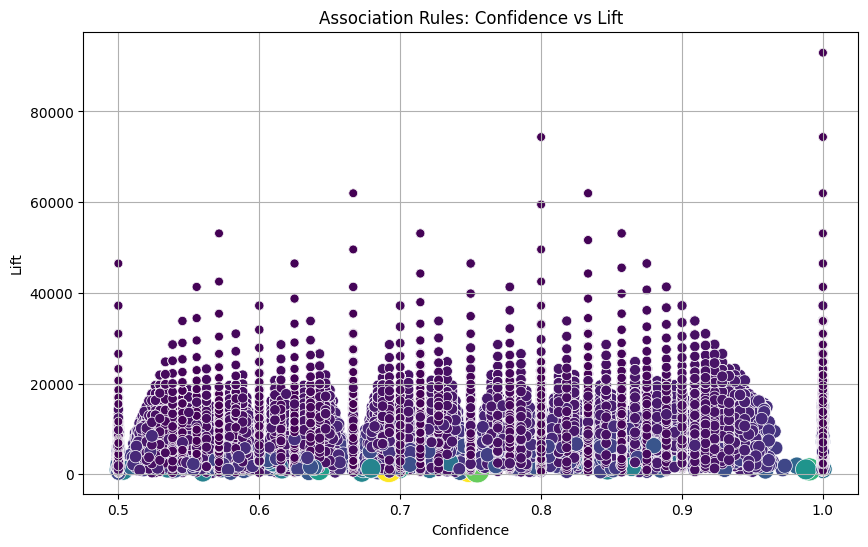

In [11]:
#Scatter plot of the association rules generated with confidence VS lift
plt.figure(figsize=(10, 6))
sns.scatterplot(data=association_rules_pd, x="confidence", y="lift", size="support", hue="support", palette="viridis", sizes=(40, 400), legend=False)
plt.title("Association Rules: Confidence vs Lift")
plt.xlabel("Confidence")
plt.ylabel("Lift")
plt.grid(True)
plt.show()


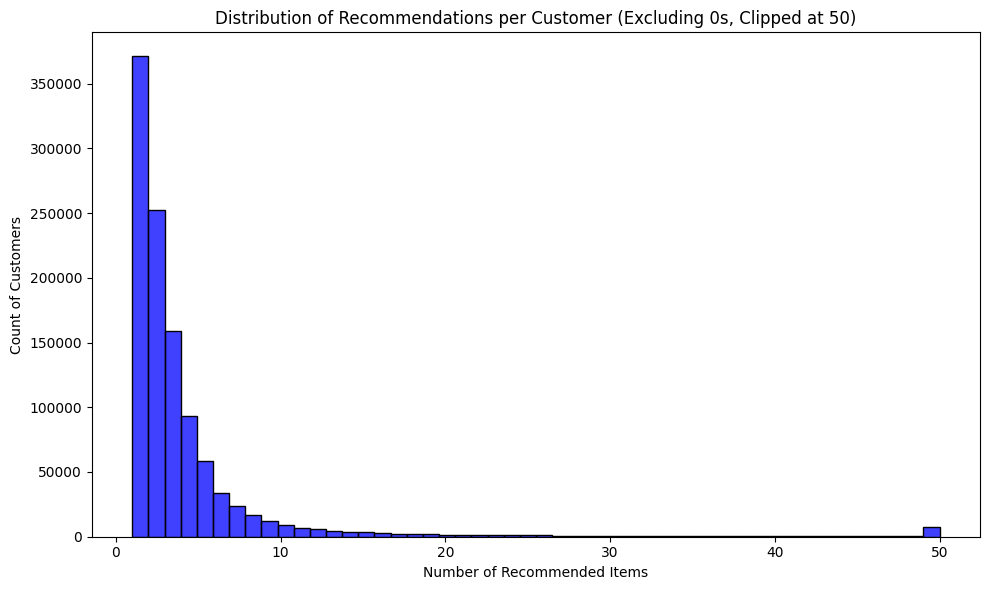

In [99]:
#Histogram of the distribution of recommendations per customer.
nonzero_recs = recommendations_pd[recommendations_pd["num_recs"] > 0]

plt.figure(figsize=(10, 6))
sns.histplot(nonzero_recs["num_recs"].clip(upper=50), bins=50, kde=False, color="blue", edgecolor="black")
plt.title("Distribution of Recommendations per Customer (Excluding 0s, Clipped at 50)")
plt.xlabel("Number of Recommended Items")
plt.ylabel("Count of Customers")
plt.tight_layout()
plt.show()

